In [50]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter, defaultdict
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── paramètres globaux ──────────────────────────────────────────────────────
WINDOW      = 1    # taille des fenêtres glissantes (années)
K_CLUSTERS  = 10   # nombre de clusters k-means
N_PCA_CLUST = 20   # composantes PCA pour le clustering
CORR_WINDOW = 5    # fenêtre corrélation glissante
EPS         = 1e-10
MIN_PATENTS = 30   # filtre de stabilité : nb min de brevets/an pour une paire
YEAR_START  = 1980
YEAR_END    = 2023

In [3]:
# ── chargement ──────────────────────────────────────────────────────────────
# Le parquet contient au minimum : publication_date, cpc4_list
df_raw = pd.read_parquet("multi_codes_brevets.parquet")
df_raw = df_raw.dropna(subset=["year", "cpc4_list"]).copy()
df_raw["year"] = df_raw["year"].astype(int)

def normalize_cpc_list(lst):
    """Conserve les 4 premiers caractères, déduplique, trie."""
    clean = []
    for c in lst:
        if c is None: continue
        s = str(c).upper().strip()
        if len(s) >= 3:
            clean.append(s[:4])
    return sorted(set(clean))

df_raw["cpc4"] = df_raw["cpc4_list"].apply(normalize_cpc_list)
df_raw = df_raw[df_raw["cpc4"].apply(len) >= 2].copy()

# pondération annuelle (correction du volume de brevets)
brevet_count_by_year = df_raw.groupby("year").size().to_dict()
N_mean = np.mean(list(brevet_count_by_year.values()))

print(f"Brevets chargés : {len(df_raw):,}")
print(f"Période : {df_raw['year'].min()} – {df_raw['year'].max()}")

Brevets chargés : 1,234,382
Période : 1980 – 2025


---
## C1 — Jaccard & probabilités conditionnelles

Pour chaque paire (i, j) et chaque année t, on calcule :
- **Jaccard** = |brevets avec i ET j| / |brevets avec i OU j|
- **P(j|i)** = |brevets avec i ET j| / |brevets avec i|
- **P(i|j)** = |brevets avec i ET j| / |brevets avec j|

On travaille sur des fenêtres glissantes de `WINDOW` ans (lissage).
La composante C1 retenue est le **Jaccard lissé** (symétrique, borné entre 0 et 1).

In [4]:
def compute_jaccard_yearly(df, window=WINDOW, min_patents=MIN_PATENTS):
    """
    Calcule l'indice de Jaccard et les probabilités conditionnelles
    pour toutes les paires actives, par fenêtre glissante.

    Retourne un DataFrame (cpc_i, cpc_j, year, jaccard, p_j_given_i, p_i_given_j)
    où year est le centre de la fenêtre.
    """
    years = sorted(df["year"].unique())
    records = []

    for t_center in years:
        t_start = t_center - window // 2
        t_end   = t_center + window // 2
        df_w = df[(df["year"] >= t_start) & (df["year"] <= t_end)]

        # comptages
        n_i     = Counter()   # brevets contenant i
        n_ij    = Counter()   # brevets contenant i ET j

        for _, row in df_w.iterrows():
            codes = row["cpc4"]
            for c in codes:
                n_i[c] += 1
            for ci, cj in itertools.combinations(codes, 2):
                key = (min(ci, cj), max(ci, cj))
                n_ij[key] += 1

        # calcul des métriques
        for (ci, cj), count_ij in n_ij.items():
            ni, nj = n_i[ci], n_i[cj]
            # filtre de stabilité
            if ni < min_patents or nj < min_patents:
                continue
            union = ni + nj - count_ij
            jaccard   = count_ij / union if union > 0 else 0
            p_j_gi    = count_ij / ni    if ni > 0   else 0
            p_i_gj    = count_ij / nj    if nj > 0   else 0
            records.append({
                "cpc_i": ci, "cpc_j": cj, "year": t_center,
                "jaccard": jaccard,
                "p_j_given_i": p_j_gi,
                "p_i_given_j": p_i_gj,
                "n_cooc": count_ij
            })

    return pd.DataFrame(records)


print("Calcul de C1 (Jaccard)...")
df_jaccard = compute_jaccard_yearly(df_raw)
print(f"  → {len(df_jaccard):,} observations (paire × année)")
df_jaccard.head()

Calcul de C1 (Jaccard)...
  → 559,194 observations (paire × année)


,cpc_i,cpc_j,year,jaccard,p_j_given_i,p_i_given_j,n_cooc
0,C07C,C07D,1980,0.104478,0.175000,0.205882,7
1,A61P,C07D,1981,0.392523,0.715909,0.464945,126
2,H01L,Y10S,1981,0.064394,0.354167,0.072961,17
3,B01J,C07F,1981,0.015625,0.027027,0.035714,2
4,B01J,C07C,1981,0.168269,0.472973,0.207101,35


---
## C2 — Corrélation temporelle glissante

Pour chaque paire (i, j), on construit deux séries temporelles (le nombre de co-occurrences
de i avec l'ensemble du réseau chaque année, et idem pour j), puis on calcule la corrélation
de Pearson sur une fenêtre glissante.

Une corrélation élevée et **stable** → les deux domaines évoluent en synchronie → signal de convergence.

In [5]:
def build_activity_series(df):
    """
    Pour chaque code CPC4 et chaque année, calcule le nombre total
    de co-occurrences pondérées avec tous ses voisins.
    Retourne un DataFrame (cpc4, year, activity).
    """
    records = []
    for year, grp in df.groupby("year"):
        N_year = brevet_count_by_year[year]
        w_year = N_mean / N_year
        activity = defaultdict(float)
        for _, row in grp.iterrows():
            codes = row["cpc4"]
            m = len(codes)
            if m < 2: continue
            w_pair = (2.0 / (m * (m - 1))) * w_year
            for c in codes:
                activity[c] += w_pair * (m - 1)
        for cpc, val in activity.items():
            records.append({"cpc4": cpc, "year": year, "activity": val})
    return pd.DataFrame(records)


def compute_rolling_corr_all_pairs(df_jaccard, df_activity, window=CORR_WINDOW):
    """
    Pour chaque paire active dans df_jaccard, calcule la corrélation
    glissante entre les séries d'activité des deux codes.

    Retourne un DataFrame (cpc_i, cpc_j, year, rolling_corr).
    """
    # pivot : (year × cpc4) pour accès rapide
    pivot = df_activity.pivot(index="year", columns="cpc4", values="activity").fillna(0)
    all_years = sorted(pivot.index)

    # paires uniques
    pairs = df_jaccard[["cpc_i", "cpc_j"]].drop_duplicates().values.tolist()

    records = []
    for ci, cj in pairs:
        if ci not in pivot.columns or cj not in pivot.columns:
            continue
        s1 = pivot[ci]
        s2 = pivot[cj]
        corr = s1.rolling(window, min_periods=3).corr(s2)
        for yr, val in corr.items():
            if not np.isnan(val):
                records.append({"cpc_i": ci, "cpc_j": cj, "year": yr, "rolling_corr": val})

    return pd.DataFrame(records)


print("Construction des séries d'activité...")
df_activity = build_activity_series(df_raw)

print("Calcul de C2 (corrélation glissante)...")
df_corr = compute_rolling_corr_all_pairs(df_jaccard, df_activity)
print(f"  → {len(df_corr):,} observations (paire × année)")
df_corr.head()

Construction des séries d'activité...
Calcul de C2 (corrélation glissante)...
  → 2,949,204 observations (paire × année)


,cpc_i,cpc_j,year,rolling_corr
0,C07C,C07D,1982,-0.640432
1,C07C,C07D,1983,0.219571
2,C07C,C07D,1984,0.471888
3,C07C,C07D,1985,0.914819
4,C07C,C07D,1986,0.950541


---
## C3 — Centralité croisée

On utilise les résultats de centralité déjà calculés (`centrality_results.csv`).

Pour une paire (i, j) à l'année t, on définit :

$$C3_{i,j,t} = \sqrt{\text{strength\_norm}(i,t) \times \text{strength\_norm}(j,t)}$$

La moyenne géométrique pénalise les paires où l'un des deux domaines est périphérique
(une convergence entre un code central et un code marginal est moins significative).

In [6]:
# ── chargement et normalisation de la centralité ────────────────────────────
centrality_df = pd.read_csv("centrality_results.csv")

if "t_center" not in centrality_df.columns:
    centrality_df["t_center"] = (
        centrality_df["window_start"] + centrality_df["window_end"]
    ) / 2.0

# arrondi à l'année entière
centrality_df["year"] = centrality_df["t_center"].round().astype(int)

# normalisation min-max du strength par année
scaler = MinMaxScaler()
centrality_df["strength_norm"] = (
    centrality_df
    .groupby("year")["strength"]
    .transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())
)

# dictionnaire d'accès rapide : (cpc4, year) → strength_norm
strength_lookup = (
    centrality_df
    .set_index(["cpc4", "year"])["strength_norm"]
    .to_dict()
)


def compute_cross_centrality(df_jaccard, strength_lookup):
    """
    Pour chaque paire (cpc_i, cpc_j, year), calcule la moyenne géométrique
    des strengths normalisés des deux codes.
    """
    df = df_jaccard[["cpc_i", "cpc_j", "year"]].copy()
    df["s_i"] = df.apply(
        lambda r: strength_lookup.get((r["cpc_i"], r["year"]), np.nan), axis=1
    )
    df["s_j"] = df.apply(
        lambda r: strength_lookup.get((r["cpc_j"], r["year"]), np.nan), axis=1
    )
    # moyenne géométrique
    df["cross_centrality"] = np.sqrt(df["s_i"] * df["s_j"])
    return df[["cpc_i", "cpc_j", "year", "cross_centrality"]]


print("Calcul de C3 (centralité croisée)...")
df_centrality_cross = compute_cross_centrality(df_jaccard, strength_lookup)
print(f"  → {df_centrality_cross['cross_centrality'].notna().sum():,} valeurs non-NaN")
df_centrality_cross.head()

Calcul de C3 (centralité croisée)...
  → 524,492 valeurs non-NaN


,cpc_i,cpc_j,year,cross_centrality
0,C07C,C07D,1980,NaN
1,A61P,C07D,1981,NaN
2,H01L,Y10S,1981,NaN
3,B01J,C07F,1981,NaN
4,B01J,C07C,1981,NaN


---
## C4 — Co-appartenance à un cluster absorbant

Pour chaque paire (i, j) et chaque période, on vérifie :
1. Les deux codes appartiennent-ils au **même cluster** ?
2. Ce cluster a-t-il un **score d'absorption supérieur au 75e percentile** ?

Si oui → C4 = score d'absorption du cluster (valeur continue, pas binaire)
Si non → C4 = 0

In [51]:
# ── recalcul du clustering et du score d'absorption ─────────────────────────
# (reprend exactement la logique du notebook principal)

from collections import Counter

def build_cooc_matrix(df, year_start, year_end):
    df_w = df[(df["year"] >= year_start) & (df["year"] <= year_end)]
    df_w = df_w[df_w["cpc4"].apply(lambda x: len(x) >= 2)]
    pair_counter = Counter()
    for cpcs in df_w["cpc4"]:
        cpcs_u = sorted(set(cpcs))
        for ci, cj in itertools.combinations(cpcs_u, 2):
            pair_counter[(ci, cj)] += 1
            pair_counter[(cj, ci)] += 1
    cooc = pd.DataFrame(
        [(i, j, c) for (i, j), c in pair_counter.items()],
        columns=["cpc_i", "cpc_j", "count"]
    )
    row_sums = cooc.groupby("cpc_i")["count"].sum().rename("row_sum")
    cooc = cooc.join(row_sums, on="cpc_i")
    cooc["M_ij"] = cooc["count"] / cooc["row_sum"]
    return cooc


print("Calcul du clustering dynamique (fenêtres annuelles)...")
pca_clust  = PCA(n_components=N_PCA_CLUST, random_state=0)
kmeans_obj = KMeans(n_clusters=K_CLUSTERS, random_state=0, n_init=10)

cluster_time = []
for start in range(YEAR_START, YEAR_END - WINDOW + 2):
    end = start + WINDOW - 1
    cooc_w = build_cooc_matrix(df_raw, start, end)
    if len(cooc_w) == 0:
        continue
    M_w = cooc_w.pivot(index="cpc_i", columns="cpc_j", values="M_ij").fillna(0)
    if M_w.shape[0] < N_PCA_CLUST:
        continue
    M_pca_w  = pca_clust.fit_transform(M_w)
    clusters = kmeans_obj.fit_predict(M_pca_w)
    cluster_time.append(
        pd.DataFrame({"cpc": M_w.index, "cluster": clusters,
                      "year_start": start, "year": start + WINDOW // 2})
    )

cluster_time_df = pd.concat(cluster_time, ignore_index=True)
print(f"  → clustering calculé pour {cluster_time_df['year'].nunique()} années")

Calcul du clustering dynamique (fenêtres annuelles)...
  → clustering calculé pour 44 années


In [ ]:
def get_cpcs_in_cluster(cluster_time_df, cluster, year):
    return (
        cluster_time_df[
            (cluster_time_df["cluster"] == cluster) &
            (cluster_time_df["year"] == year)
        ]["cpc"]
        .unique()
    )

def get_cluster(cluster_time_df, cpc, year):
    return (
        cluster_time_df[
            (cluster_time_df["cpc"] == cpc) &
            (cluster_time_df["year"] == year)
        ]["cluster"]
        .unique()
    )    

#print(get_cpcs_in_cluster(cluster_time_df, 4, 1995))
#print(get_cpcs_in_cluster(cluster_time_df, 4, 1996))
#print(get_cpcs_in_cluster(cluster_time_df, 4, 1998))


#print(get_cluster(cluster_time_df, cpc='H05C',year=1996))

cluster_time_df.groupby(["year", "cluster"])["cpc"].nunique().describe()

['H05C']
['C10F' 'C12F' 'F01K' 'F03B' 'F03D' 'F03G' 'F22D' 'F23B' 'F23L' 'F24S'
 'F24T' 'G21B' 'G21C' 'G21D' 'H01M' 'H02J' 'H02S' 'H10F']
['A01B' 'A01D' 'A24C' 'A41F' 'A42B' 'A42C' 'A45F' 'A61G' 'A61N' 'A63B'
 'A63D' 'B21G' 'B24C' 'B41L' 'B41M' 'B41P' 'B81C' 'C05B' 'C14B' 'C25F'
 'D02J' 'D06G' 'D06H' 'D06P' 'D06Q' 'E02B' 'E06C' 'F25J' 'F41C' 'F41H'
 'F42D' 'G01Q' 'G03C' 'G03F' 'G06N' 'G10C' 'G11B' 'H01L' 'H10B' 'H10D'
 'H10K' 'H10N']
[]


count    440.000000
mean      61.247727
std       86.335838
min        1.000000
25%        3.000000
50%       28.000000
75%       63.000000
max      399.000000
Name: cpc, dtype: float64

In [70]:
# ── calcul du score d'absorption ────────────────────────────────────────────
def entropy_fn(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

# transitions
df_cl = cluster_time_df.sort_values(["cpc", "year"]).copy()
transitions = []
for cpc, sub in df_cl.groupby("cpc"):
    sub = sub.sort_values("year")
    for i in range(len(sub) - 1):
        transitions.append({
            "cpc": cpc,
            "year_t":  sub.iloc[i]["year"],
            "year_t1": sub.iloc[i+1]["year"],
            "cluster_t":  sub.iloc[i]["cluster"],
            "cluster_t1": sub.iloc[i+1]["cluster"],
        })
trans_df = pd.DataFrame(transitions)

# entropie des entrées
inflow = (
    trans_df
    .groupby(["year_t1", "cluster_t1"])["cluster_t"]
    .value_counts(normalize=True).rename("p").reset_index()
)
inflow_H = (
    inflow.groupby(["year_t1", "cluster_t1"])["p"]
    .apply(entropy_fn).reset_index(name="H_in")
)

# persistance
persist = (
    trans_df
    .groupby(["year_t", "cluster_t"])
    .apply(lambda x: np.mean(x["cluster_t1"] == x["cluster_t"]))
    .reset_index(name="persistence")
)

absorption_df = inflow_H.merge(
    persist,
    left_on=["year_t1", "cluster_t1"],
    right_on=["year_t", "cluster_t"],
    how="left"
).drop(columns=["year_t", "cluster_t"])
absorption_df = absorption_df.rename(columns={"year_t1": "year", "cluster_t1": "cluster"})
absorption_df["absorption_score"] = absorption_df["H_in"] * absorption_df["persistence"].fillna(0)

# seuil absorbant
H_thresh = absorption_df["H_in"].quantile(0.30)
P_thresh = absorption_df["persistence"].quantile(0.70)

print(H_thresh)
print(P_thresh)

n=1 # nombre de périodes sur lesquelles on regarde la persistence

absorption_df["persistence_n"] = (
    absorption_df
    .groupby("cluster")["persistence"]
    .transform(lambda x: x.rolling(window=n).min().shift(-(n-1)))
)
absorption_df["persistence_n"] = (
    absorption_df
    .groupby("cluster")
    .apply(lambda df: df["persistence_n"].fillna(df["persistence"]))
    .reset_index(level=0, drop=True)
)
 # de sorte à quand même assigner une valeur de persistence pour les n dernières années



absorption_df["is_absorbing"] = (
    (absorption_df["H_in"] >= H_thresh) &
    (absorption_df["persistence_n"] > 0)
)

print(absorption_df[absorption_df["year"]==1995])
print(f"Clusters absorbants : {absorption_df['is_absorbing'].sum()} / {len(absorption_df)}")

0.32381566267106526
0.03755268952500784
     year  cluster      H_in  persistence  absorption_score  persistence_n  \
134  1995        0  1.200240     0.271186          0.325489       0.271186   
135  1995        1  1.085976     0.002681          0.002911       0.002681   
136  1995        2  0.923099     0.640625          0.591361       0.640625   
137  1995        3 -0.000000     1.000000         -0.000000       1.000000   
138  1995        4 -0.000000     1.000000         -0.000000       1.000000   
139  1995        5  0.808270     0.117647          0.095091       0.117647   
140  1995        6 -0.000000     0.000000         -0.000000       0.000000   
141  1995        7 -0.000000     0.000000         -0.000000       0.000000   
142  1995        8  0.718158     0.133333          0.095754       0.133333   
143  1995        9  1.098612     0.000000          0.000000       0.000000   

     is_absorbing  
134          True  
135          True  
136          True  
137         False  
1

     year  persistence  persistence_n
10   1982     0.000000       0.000000
20   1983     0.000000       0.000000
30   1984     0.000000       0.000000
40   1985     0.162162       0.162162
50   1986     0.000000       0.000000
60   1987     0.000000       0.000000
70   1988     0.812500       0.812500
80   1989     0.777778       0.777778
90   1990     0.055556       0.055556
99   1991     0.149847       0.149847
109  1992     0.011905       0.011905
119  1993     0.000000       0.000000
129  1994     1.000000       1.000000
139  1995     0.117647       0.117647
149  1996     0.000000       0.000000
159  1997     0.052632       0.052632
169  1998     0.180328       0.180328
179  1999     0.621622       0.621622
189  2000     0.225352       0.225352
199  2001     0.000000       0.000000
209  2002     0.000000       0.000000
219  2003     0.000000       0.000000
229  2004     0.000000       0.000000
239  2005     0.000000       0.000000
249  2006     0.000000       0.000000
259  2007   

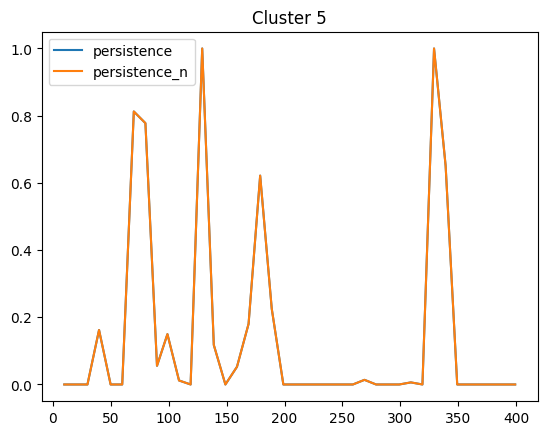

In [71]:
cluster_test = 5  # au choix

df_test = (
    absorption_df[absorption_df["cluster"] == cluster_test]
    .sort_values("year")
    [["year", "persistence", "persistence_n"]]

    
)

print(df_test)

df_plot = df_test.copy()

plt.plot(df_plot["persistence"], label="persistence")
plt.plot(df_plot["persistence_n"], label="persistence_n")

plt.legend()
plt.title(f"Cluster {cluster_test}")
plt.show()

In [72]:
# ── construction de C4 au niveau paire ──────────────────────────────────────
def compute_cluster_component(df_jaccard, cluster_time_df, absorption_df):
    """
    Pour chaque paire (cpc_i, cpc_j, year), retourne :
    - same_cluster : booléen, les deux codes sont dans le même cluster
    - absorption_score : score du cluster s'ils sont co-localisés dans un
                         cluster absorbant, sinon 0
    """
    # lookup cluster : (cpc, year) → cluster
    cluster_lookup = (
        cluster_time_df
        .set_index(["cpc", "year"])["cluster"]
        .to_dict()
    )
    # lookup absorption : (year, cluster) → absorption_score
    absorb_lookup = (
        absorption_df
        .set_index(["year", "cluster"])["absorption_score"]
        .to_dict()
    )

    df = df_jaccard[["cpc_i", "cpc_j", "year"]].copy()

    def row_c4(r):
        cl_i = cluster_lookup.get((r["cpc_i"], r["year"]))
        cl_j = cluster_lookup.get((r["cpc_j"], r["year"]))
        if cl_i is None or cl_j is None or cl_i != cl_j:
            return 0.0
        return absorb_lookup.get((r["year"], cl_i), 0.0)

    df["cluster_absorption"] = df.apply(row_c4, axis=1)
    return df[["cpc_i", "cpc_j", "year", "cluster_absorption"]]


print("Calcul de C4 (co-appartenance cluster absorbant)...")
df_cluster_c4 = compute_cluster_component(df_jaccard, cluster_time_df, absorption_df)
print(f"  → paires dans un cluster absorbant : "
      f"{(df_cluster_c4['cluster_absorption'] > 0).sum():,}")
df_cluster_c4.head()

Calcul de C4 (co-appartenance cluster absorbant)...
  → paires dans un cluster absorbant : 139,580


,cpc_i,cpc_j,year,cluster_absorption
0,C07C,C07D,1980,0.000000
1,A61P,C07D,1981,0.581677
2,H01L,Y10S,1981,0.000000
3,B01J,C07F,1981,0.581677
4,B01J,C07C,1981,0.581677


---
## Assemblage du panel (cpc_i, cpc_j, year)

In [73]:
# ── jointures successives ────────────────────────────────────────────────────
keys = ["cpc_i", "cpc_j", "year"]

panel = (
    df_jaccard[["cpc_i", "cpc_j", "year", "jaccard", "p_j_given_i", "p_i_given_j", "n_cooc"]]
    .merge(df_corr[["cpc_i", "cpc_j", "year", "rolling_corr"]], on=keys, how="left")
    .merge(df_centrality_cross[["cpc_i", "cpc_j", "year", "cross_centrality"]], on=keys, how="left")
    .merge(df_cluster_c4[["cpc_i", "cpc_j", "year", "cluster_absorption"]], on=keys, how="left")
)

# remplissages manquants
panel["rolling_corr"]      = panel["rolling_corr"].fillna(0)
panel["cross_centrality"]  = panel["cross_centrality"].fillna(0)
panel["cluster_absorption"]= panel["cluster_absorption"].fillna(0)

print(f"Panel : {len(panel):,} lignes, {panel['cpc_i'].nunique() + panel['cpc_j'].nunique()} codes uniques")
panel.head()

Panel : 559,194 lignes, 1098 codes uniques


,cpc_i,cpc_j,year,jaccard,p_j_given_i,p_i_given_j,n_cooc,rolling_corr,cross_centrality,cluster_absorption
0,C07C,C07D,1980,0.104478,0.175000,0.205882,7,0.0,0.0,0.000000
1,A61P,C07D,1981,0.392523,0.715909,0.464945,126,0.0,0.0,0.581677
2,H01L,Y10S,1981,0.064394,0.354167,0.072961,17,0.0,0.0,0.000000
3,B01J,C07F,1981,0.015625,0.027027,0.035714,2,0.0,0.0,0.581677
4,B01J,C07C,1981,0.168269,0.472973,0.207101,35,0.0,0.0,0.581677


---
## Normalisation Min-Max des 4 composantes

Avant l'agrégation, chaque composante est ramenée à [0, 1].
La corrélation glissante est d'abord décalée de +1 (pour gérer les valeurs négatives)
puis normalisée.

In [80]:
# corrélation ∈ [-1, 1] → décaler à [0, 2] avant normalisation
panel["rolling_corr_shifted"] = panel["rolling_corr"].clip(lower=0)

components = [
    ("C1_jaccard",          "jaccard"),
    ("C2_corr",             "rolling_corr_shifted"),
    ("C3_centrality",       "cross_centrality"),
    ("C4_cluster",          "cluster_absorption"),
]

scaler_mm = MinMaxScaler()
raw_cols  = [c[1] for c in components]
norm_cols = [c[0] for c in components]

panel[norm_cols] = scaler_mm.fit_transform(panel[raw_cols])

panel[norm_cols].describe()
panel

,cpc_i,cpc_j,year,jaccard,p_j_given_i,p_i_given_j,n_cooc,rolling_corr,cross_centrality,cluster_absorption,rolling_corr_shifted,C1_jaccard,C2_corr,C3_centrality,C4_cluster
0,C07C,C07D,1980,0.104478,0.175000,0.205882,7,0.000000,0.0,0.000000,0.000000,0.112660,0.000000,0.0,0.000000
1,A61P,C07D,1981,0.392523,0.715909,0.464945,126,0.000000,0.0,0.581677,0.000000,0.423531,0.000000,0.0,0.579911
2,H01L,Y10S,1981,0.064394,0.354167,0.072961,17,0.000000,0.0,0.000000,0.000000,0.069400,0.000000,0.0,0.000000
3,B01J,C07F,1981,0.015625,0.027027,0.035714,2,0.000000,0.0,0.581677,0.000000,0.016767,0.000000,0.0,0.579911
4,B01J,C07C,1981,0.168269,0.472973,0.207101,35,0.000000,0.0,0.581677,0.000000,0.181506,0.000000,0.0,0.579911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559189,A23L,B05B,2025,0.009346,0.015873,0.022222,1,-0.555223,0.0,0.000000,0.000000,0.009990,0.000000,0.0,0.000000
559190,A23V,B05B,2025,0.011111,0.021739,0.022222,1,-0.794394,0.0,0.000000,0.000000,0.011895,0.000000,0.0,0.000000
559191,A47J,F16B,2025,0.010309,0.027778,0.016129,1,-0.236395,0.0,0.000000,0.000000,0.011030,0.000000,0.0,0.000000
559192,F16B,H05B,2025,0.006135,0.016129,0.009804,1,0.223308,0.0,0.000000,0.223308,0.006525,0.223308,0.0,0.000000


---
## Agrégation par PCA (1 composante)

On laisse les données décider des poids. La première composante principale
capture la variance commune aux 4 signaux.

On vérifie ensuite que les loadings ont bien tous le même signe
(si ce n'est pas le cas, l'indice est difficile à interpréter).

In [81]:
# ── PCA à 1 composante ───────────────────────────────────────────────────────
X = panel[norm_cols].values

pca_index = PCA(n_components=1, random_state=0)
scores    = pca_index.fit_transform(X).flatten()

loadings = pca_index.components_[0]
var_exp  = pca_index.explained_variance_ratio_[0]

print(f"Variance expliquée par PC1 : {var_exp:.1%}")
print("\nLoadings (contributions de chaque composante) :")
for name, loading in zip(norm_cols, loadings):
    print(f"  {name:25s} : {loading:+.4f}")

# si certains loadings sont négatifs, on inverse le signe de l'indice
if loadings.mean() < 0:
    scores = -scores
    print("\n⚠ Signe inversé (convention : indice élevé = forte convergence)")

# normalisation finale → [0, 1]
panel["CI_pca"] = MinMaxScaler().fit_transform(scores.reshape(-1, 1)).flatten()

print(f"\nIndice CI_pca : min={panel['CI_pca'].min():.4f}, max={panel['CI_pca'].max():.4f}, "
      f"mean={panel['CI_pca'].mean():.4f}")

Variance expliquée par PC1 : 79.8%

Loadings (contributions de chaque composante) :
  C1_jaccard                : +0.0098
  C2_corr                   : +0.9999
  C3_centrality             : +0.0051
  C4_cluster                : +0.0024

Indice CI_pca : min=0.0000, max=1.0000, mean=0.2754


In [91]:
# ── alternative : pondération ad hoc (à conserver pour comparaison) ──────────
W = {"C1_jaccard": 0.25, "C2_corr": 0.25, "C3_centrality": 0.25, "C4_cluster": 0.25}

#panel["CI_weighted"] = (panel["C1_jaccard"]*panel["C2_corr"]*panel["C3_centrality"]*panel["C4_cluster"])**0.25
panel["CI_weighted"] = sum(
    w * panel[col] for col, w in W.items()
)

print("Corrélation entre CI_pca et CI_weighted :",
      panel[["CI_pca", "CI_weighted"]].corr().iloc[0, 1].round(3))


Corrélation entre CI_pca et CI_weighted : 0.896


---
## Validation sur les cas connus ("ground truth")

On valide l'indice sur deux convergences documentées :
1. **C12N × A61K** : biologie moléculaire → pharmacie (attendu après ~1995)
2. **H01M × B60L** : batteries → propulsion électrique (attendu après ~2012)

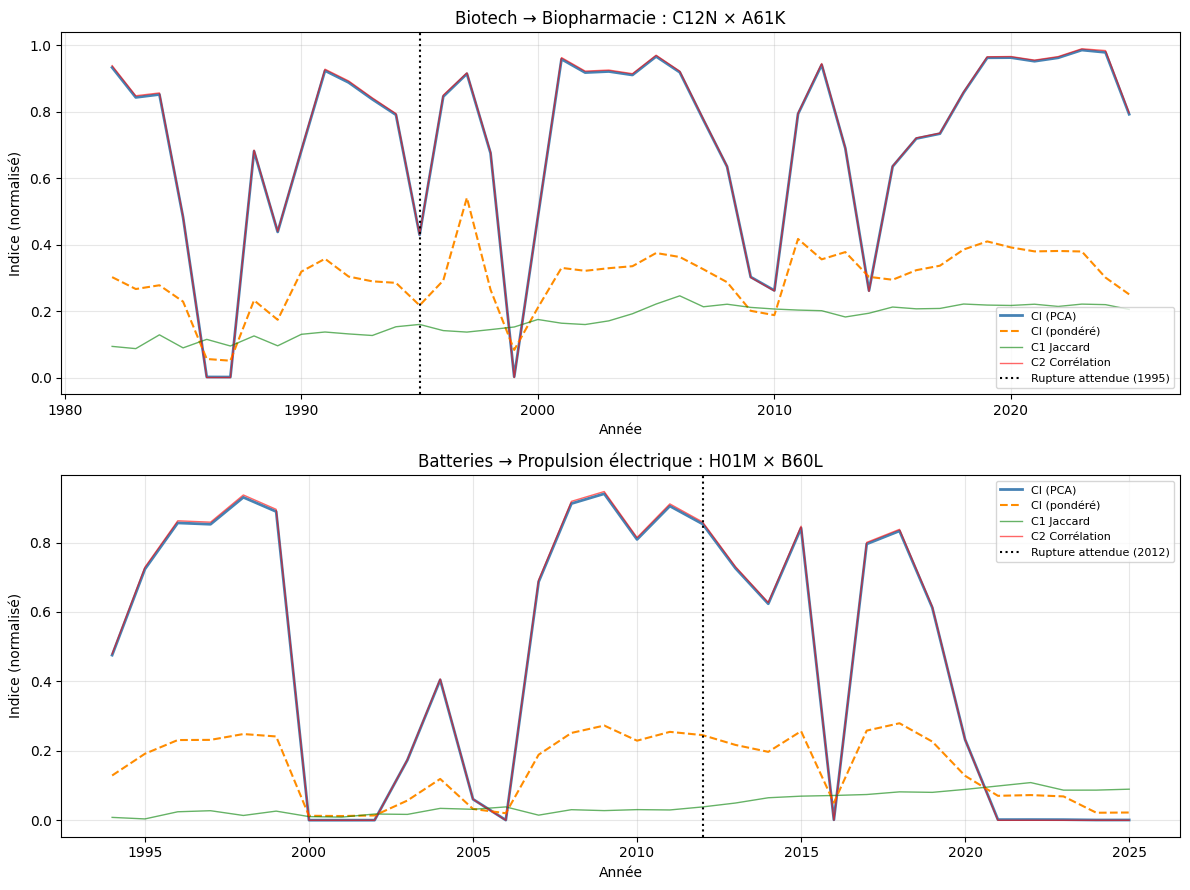

In [92]:
def plot_pair_validation(panel, ci, cj, label, expected_break, ax=None):
    """Trace l'évolution de CI_pca pour une paire donnée."""
    mask = (
        ((panel["cpc_i"] == ci) & (panel["cpc_j"] == cj)) |
        ((panel["cpc_i"] == cj) & (panel["cpc_j"] == ci))
    )
    sub = panel[mask].sort_values("year")

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(sub["year"], sub["CI_pca"],     label="CI (PCA)",      color="steelblue",  lw=2)
    ax.plot(sub["year"], sub["CI_weighted"],label="CI (pondéré)",  color="darkorange", lw=1.5, ls="--")
    ax.plot(sub["year"], sub["C1_jaccard"], label="C1 Jaccard",    color="green",      lw=1, alpha=0.6)
    ax.plot(sub["year"], sub["C2_corr"],    label="C2 Corrélation",color="red",        lw=1, alpha=0.6)
    ax.axvline(expected_break, color="black", ls=":", lw=1.5, label=f"Rupture attendue ({expected_break})")
    ax.set_title(f"{label} : {ci} × {cj}")
    ax.set_xlabel("Année")
    ax.set_ylabel("Indice (normalisé)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    return ax


fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_pair_validation(panel, "C12N", "A61K",
                     "Biotech → Biopharmacie", expected_break=1995, ax=axes[0])
plot_pair_validation(panel, "H01M", "B60L",
                     "Batteries → Propulsion électrique", expected_break=2012, ax=axes[1])
plt.tight_layout()
plt.savefig("validation_ground_truth.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Analyse des redondances entre composantes

On vérifie que les 4 composantes apportent bien des informations distinctes
(matrice de corrélation et scatter plots).

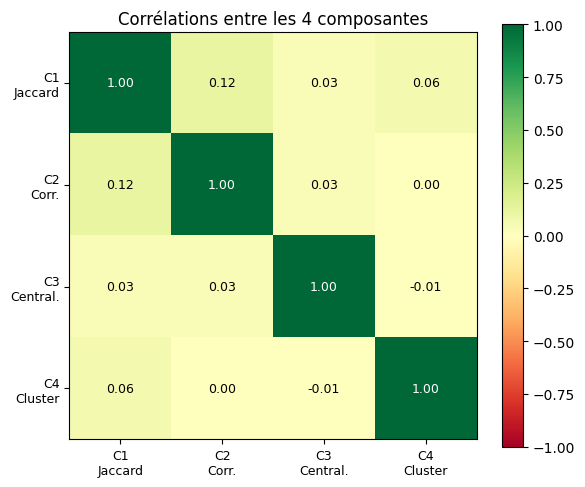


Si C1 et C2 sont très corrélées (> 0.8), envisager de les fusionner.


In [93]:
# ── matrice de corrélation entre composantes ─────────────────────────────────
corr_matrix = panel[norm_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(norm_cols)))
ax.set_yticks(range(len(norm_cols)))
labels_short = ["C1\nJaccard", "C2\nCorr.", "C3\nCentral.", "C4\nCluster"]
ax.set_xticklabels(labels_short, fontsize=9)
ax.set_yticklabels(labels_short, fontsize=9)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="black" if abs(corr_matrix.iloc[i,j]) < 0.7 else "white")
ax.set_title("Corrélations entre les 4 composantes")
plt.tight_layout()
plt.savefig("correlation_composantes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSi C1 et C2 sont très corrélées (> 0.8), envisager de les fusionner.")

---
## Top convergences par année

On identifie les paires les plus convergentes pour chaque période
(utile pour l'analyse économique et la présentation des résultats).

In [94]:
def top_convergences(panel, year, n=15):
    """Retourne les n paires les plus convergentes à une année donnée."""
    return (
        panel[panel["year"] == year]
        .nlargest(n, "CI_weighted")[["cpc_i", "cpc_j", "CI_weighted",
                                  "C1_jaccard", "C2_corr",
                                  "C3_centrality", "C4_cluster"]]
        .reset_index(drop=True)
    )

# exemples pour 3 années clés
for yr in [1995, 2010, 2020]:
    print(f"\n── Top 10 convergences en {yr} ──────────────────────────────")
    display(top_convergences(panel, yr, n=10))


── Top 10 convergences en 1995 ──────────────────────────────


,cpc_i,cpc_j,CI_weighted,C1_jaccard,C2_corr,C3_centrality,C4_cluster
0,Y10S,Y10T,0.514591,0.128151,0.928527,0.998785,0.002903
1,D04B,D10B,0.478422,0.372498,0.938529,0.013095,0.589565
2,B29C,C08J,0.429035,0.089840,0.909399,0.127336,0.589565
3,H01R,H05K,0.419957,0.107968,0.858683,0.123614,0.589565
4,B60T,H05K,0.418353,0.006151,0.991846,0.085850,0.589565
5,C10M,C10N,0.406169,0.729978,0.869442,0.022352,0.002903
6,F16C,F16H,0.404158,0.012726,0.937483,0.076857,0.589565
7,B32B,B60S,0.403990,0.002692,0.988903,0.034801,0.589565
8,F16C,H01R,0.401665,0.001955,0.937222,0.077919,0.589565
9,B23Q,F16L,0.399215,0.007839,0.928078,0.071377,0.589565



── Top 10 convergences en 2010 ──────────────────────────────


,cpc_i,cpc_j,CI_weighted,C1_jaccard,C2_corr,C3_centrality,C4_cluster
0,A61K,A61P,0.501149,0.563356,0.936095,0.505145,0.000000
1,C10M,C10N,0.461496,0.814068,0.920849,0.008962,0.102106
2,H01M,Y02E,0.453769,0.622709,0.992728,0.199640,0.000000
3,A61P,C07D,0.432591,0.408753,0.852597,0.469014,0.000000
4,E05F,E05Y,0.402620,0.583755,0.904184,0.020435,0.102106
5,A61K,C07D,0.381930,0.192863,0.948113,0.386746,0.000000
6,F03D,F05B,0.362915,0.569925,0.863475,0.018259,0.000000
7,C01P,C09C,0.360791,0.536475,0.784625,0.019957,0.102106
8,B81B,B81C,0.350943,0.407164,0.885184,0.009317,0.102106
9,A61K,C07K,0.341487,0.316717,0.731737,0.317496,0.000000



── Top 10 convergences en 2020 ──────────────────────────────


,cpc_i,cpc_j,CI_weighted,C1_jaccard,C2_corr,C3_centrality,C4_cluster
0,A61K,A61P,0.567075,0.717871,0.988761,0.561669,0.000000
1,G06F,H04L,0.535200,0.337124,0.996996,0.806679,0.000000
2,F01D,F05D,0.492165,0.714372,0.992100,0.225276,0.036912
3,C10M,C10N,0.470437,0.866651,0.995450,0.019649,0.000000
4,H04L,H04W,0.442810,0.305671,0.979531,0.486038,0.000000
5,H01M,Y02E,0.436558,0.429963,0.870711,0.445559,0.000000
6,G06F,H04N,0.435550,0.112251,0.993318,0.636632,0.000000
7,G06F,H04W,0.429440,0.132466,0.982538,0.602758,0.000000
8,F03D,F05B,0.427808,0.635153,0.996470,0.079609,0.000000
9,A61P,C07D,0.427806,0.314780,0.991918,0.404525,0.000000


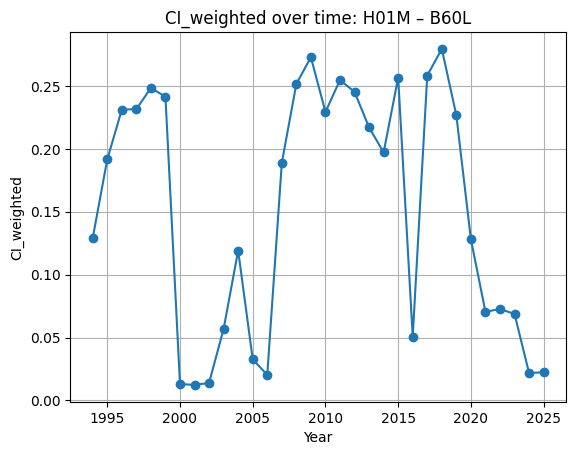

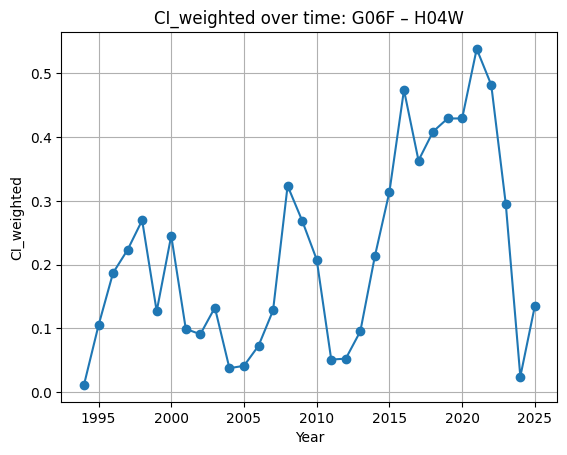

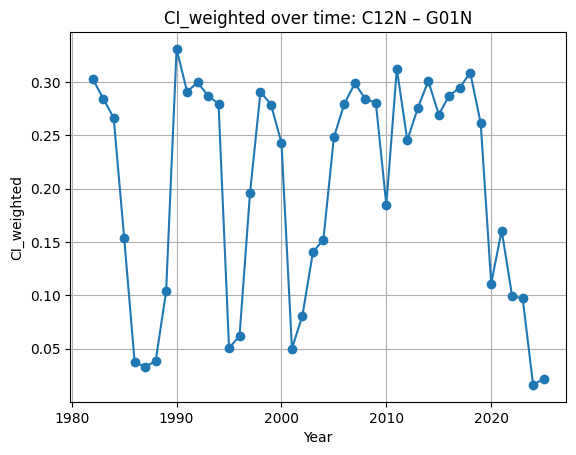

In [97]:
import matplotlib.pyplot as plt

def plot_ci_pair(panel, cpc_i, cpc_j):
    df = panel[
        ((panel["cpc_i"] == cpc_i) & (panel["cpc_j"] == cpc_j)) |
        ((panel["cpc_i"] == cpc_j) & (panel["cpc_j"] == cpc_i))
    ].sort_values("year")

    plt.figure()
    plt.plot(df["year"], df["CI_weighted"], marker="o")
    plt.title(f"CI_weighted over time: {cpc_i} – {cpc_j}")
    plt.xlabel("Year")
    plt.ylabel("CI_weighted")
    plt.grid(True)
    plt.show()

plot_ci_pair(panel,"H01M","B60L")
plot_ci_pair(panel,"G06F","H04W")
plot_ci_pair(panel,"C12N","G01N")




---
## Évolution temporelle de l'indice agrégé

On représente l'évolution du CI moyen par année (toutes paires confondues)
pour avoir une vue macroscopique des vagues d'innovation.

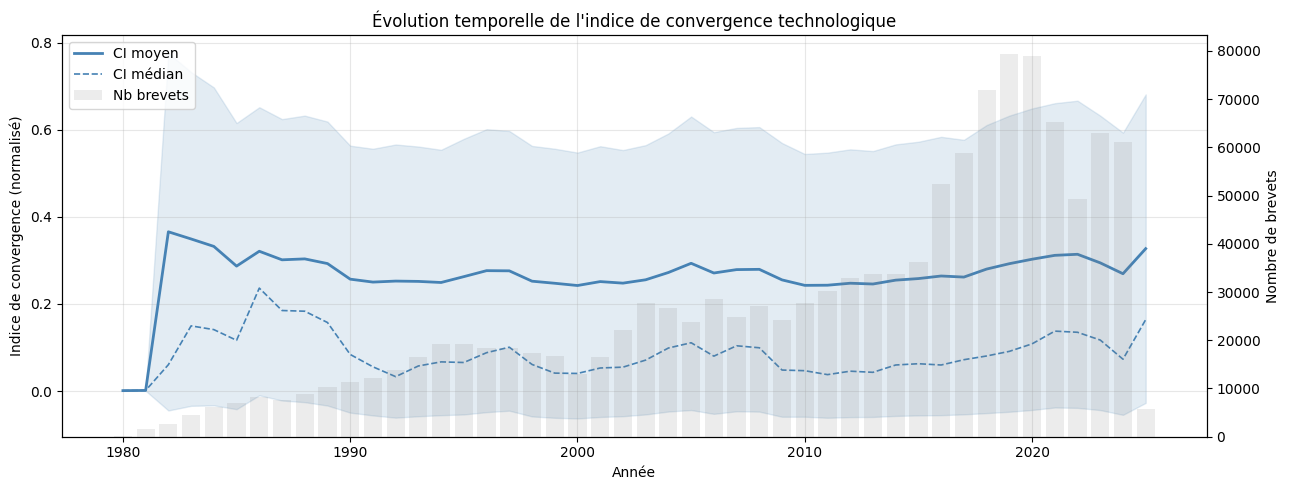

In [87]:
# ── série temporelle agrégée ─────────────────────────────────────────────────
# Normalisation par le nombre de brevets (correction biais de volume)
yearly_patents = pd.Series(brevet_count_by_year).rename("n_patents")

CI_time = (
    panel.groupby("year")["CI_pca"]
    .agg(["mean", "median", "std"])
    .join(yearly_patents)
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.fill_between(
    CI_time.index,
    CI_time["mean"] - CI_time["std"],
    CI_time["mean"] + CI_time["std"],
    alpha=0.15, color="steelblue"
)
ax1.plot(CI_time.index, CI_time["mean"],   label="CI moyen",   color="steelblue", lw=2)
ax1.plot(CI_time.index, CI_time["median"], label="CI médian",  color="steelblue", lw=1.2, ls="--")
ax2.bar(CI_time.index, CI_time["n_patents"], alpha=0.15, color="gray", label="Nb brevets")

ax1.set_xlabel("Année")
ax1.set_ylabel("Indice de convergence (normalisé)")
ax2.set_ylabel("Nombre de brevets")
ax1.set_title("Évolution temporelle de l'indice de convergence technologique")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("CI_temporal_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Export final

In [19]:
# ── export ────────────────────────────────────────────────────────────────────
cols_export = [
    "cpc_i", "cpc_j", "year",
    "C1_jaccard", "C2_corr", "C3_centrality", "C4_cluster",
    "CI_pca", "CI_weighted",
    "jaccard", "p_j_given_i", "p_i_given_j",
    "rolling_corr", "n_cooc"
]
panel[cols_export].to_parquet("indice_convergence_final.parquet", index=False)
panel[cols_export].to_csv("indice_convergence_final.csv", index=False)

print("Fichiers exportés :")
print("  → indice_convergence_final.parquet")
print("  → indice_convergence_final.csv")
print(f"  → {len(panel):,} lignes, {panel['year'].nunique()} années")
panel[cols_export].describe()

Fichiers exportés :
  → indice_convergence_final.parquet
  → indice_convergence_final.csv
  → 559,194 lignes, 46 années


,year,C1_jaccard,C2_corr,C3_centrality,C4_cluster,CI_pca,CI_weighted,jaccard,p_j_given_i,p_i_given_j,rolling_corr,n_cooc
count,559194.000000,559194.000000,559194.000000,559194.000000,559194.000000,559194.000000,559194.000000,559194.000000,559194.000000,559194.000000,559194.000000,559194.000000
mean,2011.900337,0.010991,0.528314,0.059204,0.045162,0.524797,0.002608,0.010273,0.034513,0.026470,0.056627,8.653752
std,10.256415,0.027342,0.284347,0.058589,0.152120,0.281260,0.010544,0.025335,0.071381,0.059881,0.568695,40.733484
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000089,0.000131,0.000120,-1.000000,1.000000
25%,2005.000000,0.001817,0.282393,0.024078,0.000000,0.281507,0.000000,0.001773,0.005000,0.003515,-0.435215,1.000000
50%,2015.000000,0.004152,0.541782,0.043054,0.000000,0.538108,0.000000,0.003937,0.012848,0.009328,0.083565,2.000000
75%,2020.000000,0.009850,0.779789,0.074919,0.000000,0.773529,0.000000,0.009217,0.030769,0.024390,0.559579,5.000000
max,2025.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.475140,0.926667,1.000000,1.000000,1.000000,4249.000000
